# Homework 04 - Module 04 evaluation

> Note: sometimes your answer doesn’t match one of the options exactly.
> That’s fine. Select the option that’s closest to your solution.

In this homework, we will use the lead scoring dataset Bank Marketing
dataset. Download it from
[here](https://raw.githubusercontent.com/alexeygrigorev/datasets/master/course_lead_scoring.csv).

In this dataset our desired target for classification task will be
`converted` variable - has the client signed up to the platform or not.

# import packages

In [31]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from matplotlib import pyplot as plt


In [2]:
pd.set_option('max_colwidth', 1000)
pd.set_option("display.precision", 4)

# load data

In [3]:
path="https://raw.githubusercontent.com/alexeygrigorev/datasets/master/course_lead_scoring.csv"

In [4]:
dataset = pd.read_csv(path)

## Data preparation

Check if the missing values are presented in the features.
-   If there are missing values:
    -   For caterogiral features, replace them with ‘NA’
    -   For numerical features, replace with with 0.0

Split the data into 3 parts: train/validation/test with 60%/20%/20%
distribution. Use `train_test_split` function for that with
`random_state=1`

In [5]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1462 entries, 0 to 1461
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   lead_source               1334 non-null   object 
 1   industry                  1328 non-null   object 
 2   number_of_courses_viewed  1462 non-null   int64  
 3   annual_income             1281 non-null   float64
 4   employment_status         1362 non-null   object 
 5   location                  1399 non-null   object 
 6   interaction_count         1462 non-null   int64  
 7   lead_score                1462 non-null   float64
 8   converted                 1462 non-null   int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 102.9+ KB


In [6]:
dataset.head(5)

,lead_source,industry,number_of_courses_viewed,annual_income,employment_status,location,interaction_count,lead_score,converted
0,paid_ads,NaN,1,79450.0,unemployed,south_america,4,0.94,1
1,social_media,retail,1,46992.0,employed,south_america,1,0.80,0
2,events,healthcare,5,78796.0,unemployed,australia,3,0.69,1
3,paid_ads,retail,2,83843.0,NaN,australia,1,0.87,0
4,referral,education,3,85012.0,self_employed,europe,3,0.62,1


In [7]:
dataset.isnull().sum()

lead_source                 128
industry                    134
number_of_courses_viewed      0
annual_income               181
employment_status           100
location                     63
interaction_count             0
lead_score                    0
converted                     0
dtype: int64

In [8]:
df=dataset.copy()

In [9]:
categorical_columns = list(df.dtypes[df.dtypes == 'object'].index)

numerical_columns=list(df.dtypes[df.dtypes=='float64'].index)

for a in list(df.dtypes[df.dtypes=='int64'].index):
    numerical_columns.append(a)
    

print("categorical_columns:",categorical_columns)
print("numerical_columns:",numerical_columns)

categorical_columns: ['lead_source', 'industry', 'employment_status', 'location']
numerical_columns: ['annual_income', 'lead_score', 'number_of_courses_viewed', 'interaction_count', 'converted']


In [10]:
for var in df.columns:
    
    if df[var].dtypes== 'object':
        df[var]=df[var].fillna(value='NA')   

    else:
        df[var]=df[var].fillna(value=0)
            

In [11]:
df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=1)
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=1)

In [12]:
print('total',df.shape)
print('full train',df_full_train.shape)
print('train',df_train.shape)
print('val',df_val.shape)
print('test',df_test.shape)

print('---')
print('total:',df.shape[0])
print('train',df.shape[0]*0.6)
print('val',df.shape[0]*0.2)
print('test',df.shape[0]*0.2)


total (1462, 9)
full train (1169, 9)
train (876, 9)
val (293, 9)
test (293, 9)
---
total: 1462
train 877.1999999999999
val 292.40000000000003
test 292.40000000000003


In [13]:
df_full_train = df_full_train.reset_index(drop=True)
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

In [14]:
y_full_train = df_full_train.converted.values
y_train = df_train.converted.values
y_val = df_val.converted.values
y_test = df_test.converted.values

del df_full_train['converted']
del df_train['converted']
del df_val['converted']
del df_test['converted'] 

In [15]:
numerical_columns.remove('converted')

In [16]:
from sklearn.feature_extraction import DictVectorizer
 
train_dicts = df_train[categorical_columns + numerical_columns].to_dict(orient='records')
dv = DictVectorizer(sparse=False)
 
dv.fit(train_dicts)
X_train = dv.transform(train_dicts)
# instead of last two lines, you can also use
# X_train = dv.fit_transform(train_dicts)
 
X_train.shape

(876, 31)

In [17]:
val_dicts = df_val[categorical_columns + numerical_columns].to_dict(orient='records')
X_val = dv.transform(val_dicts)

In [18]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(solver='liblinear', C=1.0, max_iter=1000, random_state=42)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=42, solver='liblinear')

In [19]:
#model.coef_[0].round(5)
#model.intercept_
#model.predict(X_train)
#model.predict_proba(X_train)

In [20]:
#applying to validation set
y_pred = model.predict_proba(X_val)[:,1]
y_pred
print("")

In [21]:
converted_decision = y_pred >0.5

In [22]:
accuracy_general=(y_val == converted_decision.astype(int)).mean()

accuracy_general

0.6996587030716723

## Questions

### Question 1: ROC AUC feature importance

ROC AUC could also be used to evaluate feature importance of numerical
variables.

Let’s do that

-   For each numerical variable, use it as score (aka prediction) and
    compute the AUC with the `y` variable as ground truth.
-   Use the training dataset for that

If your AUC is \< 0.5, invert this variable by putting “-” in front

(e.g. `-df_train['balance']`)

AUC can go below 0.5 if the variable is negatively correlated with the
target variable. You can change the direction of the correlation by
negating this variable - then negative correlation becomes positive.

Which numerical variable (among the following 4) has the highest AUC?

-   `lead_score`
-   `number_of_courses_viewed`
-   `interaction_count`
-   `annual_income`

In [23]:
from sklearn.metrics import roc_auc_score

for numerical in numerical_columns:
    score = roc_auc_score(y_train,df_train[numerical])
    if score<0.5:
        
        score = roc_auc_score(y_train,(-df_train[numerical]))
    print("the AUC score for the ",numerical,"is: ",score)

the AUC score for the  annual_income is:  0.5519578313253012
the AUC score for the  lead_score is:  0.6144993577250176
the AUC score for the  number_of_courses_viewed is:  0.7635680590007088
the AUC score for the  interaction_count is:  0.738270176293409


### Question 2: Training the model

Apply one-hot-encoding using `DictVectorizer` and train the logistic
regression with these parameters:

``` python
LogisticRegression(solver='liblinear', C=1.0, max_iter=1000)
```

What’s the AUC of this model on the validation dataset? (round to 3
digits)

-   0.32
-   0.52
-   0.72
-   0.92

In [26]:
from sklearn.feature_extraction import DictVectorizer
 
train_dicts = df_train[categorical_columns + numerical_columns].to_dict(orient='records')
dv = DictVectorizer(sparse=False)
 
dv.fit(train_dicts)
X_train = dv.transform(train_dicts)
# instead of last two lines, you can also use
# X_train = dv.fit_transform(train_dicts)
 
X_train.shape

val_dicts = df_val[categorical_columns + numerical_columns].to_dict(orient='records')
X_val = dv.transform(val_dicts)

from sklearn.linear_model import LogisticRegression

model = LogisticRegression(solver='liblinear', C=1.0, max_iter=1000)
model.fit(X_train, y_train)

#model.coef_[0].round(5)
#model.intercept_
#model.predict(X_train)
#model.predict_proba(X_train)

#applying to validation set
y_pred = model.predict_proba(X_val)[:,1]

#AUC

roc_auc_val = roc_auc_score(y_val, y_pred)
print("AUC val: ", round(roc_auc_val,3))


AUC val:  0.817


In [27]:
0.92-0.817

0.10300000000000009

In [29]:
0.72-0.817

-0.09699999999999998

### Question 3: Precision and Recall

Now let’s compute precision and recall for our model.

-   Evaluate the model on all thresholds from 0.0 to 1.0 with step 0.01
-   For each threshold, compute precision and recall
-   Plot them

At which threshold precision and recall curves intersect?

-   0.145
-   0.345
-   0.545
-   0.745

intersection 0.64


C:\Users\jerojasn\AppData\Local\Temp\ipykernel_2852\2245683713.py:17: RuntimeWarning: invalid value encountered in scalar divide
  p = tp / (tp + fp)


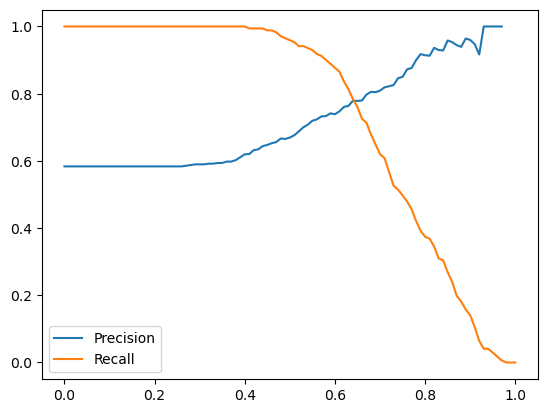

In [36]:
actual_positive = (y_val == 1)
actual_negative = (y_val == 0)

thresholds  = np.linspace(0, 1, 101) #thresholds from 0 to 1 with step 0.01
precission = []
recall = []
for t in thresholds:
    predict_positive = (y_pred >= t)
    predict_negative = (y_pred < t)

    tp = (predict_positive & actual_positive).sum()
    tn = (predict_negative & actual_negative).sum()

    fp = (predict_positive & actual_negative).sum()
    fn = (predict_negative & actual_positive).sum()

    p = tp / (tp + fp)
    r = tp / (tp + fn)
    precission.append(p)
    recall.append(r)

    if round(p, 2) == round(r, 2):
        print("intersection",t)

plt.plot(thresholds, prediction, label='Precision')
plt.plot(thresholds, recall, label='Recall')
plt.legend()

### Question 4: F1 score

Precision and recall are conflicting - when one grows, the other goes
down. That’s why they are often combined into the F1 score - a metrics
that takes into account both

This is the formula for computing F1:

$$F_1 = 2 \cdot \cfrac{P \cdot R}{P + R}$$

Where $P$ is precision and $R$ is recall.

Let’s compute F1 for all thresholds from 0.0 to 1.0 with increment 0.01

At which threshold F1 is maximal?

-   0.14
-   0.34
-   0.54
-   0.74

In [ ]:
actual_positive = (y_val == 1)
actual_negative = (y_val == 0)

thresholds  = np.linspace(0, 1, 101) #thresholds from 0 to 1 with step 0.01
precissions = []
recalls = []
f1s=[]
for t in thresholds:
    predict_positive = (y_pred >= t)
    predict_negative = (y_pred < t)

    tp = (predict_positive & actual_positive).sum()
    tn = (predict_negative & actual_negative).sum()

    fp = (predict_positive & actual_negative).sum()
    fn = (predict_negative & actual_positive).sum()

    p = tp / (tp + fp)
    r = tp / (tp + fn)
    precissions.append(p)
    recalls.append(r)

    f1 = (2 * (p * r)) / (p + r)
    f1s.append(f1)

In [44]:
cc=["threshold","precission", "recall", "f1"]
res=pd.DataFrame(list(zip(thresholds,precissions, recalls,f1s)),columns=cc)
res.describe()


,threshold,precission,recall,f1
count,101.000,98.0000,101.0000,98.0000
mean,0.500,0.7195,0.7438,0.6576
std,0.293,0.1444,0.3457,0.2020
min,0.000,0.5836,0.0000,0.0116
25%,0.250,0.5836,0.4971,0.6500
50%,0.500,0.6660,0.9591,0.7371
75%,0.750,0.8248,1.0000,0.7648
max,1.000,1.0000,1.0000,0.8125


In [45]:
res[res["f1"]==res["f1"].max()]

,threshold,precission,recall,f1
57,0.57,0.7324,0.9123,0.8125


### Question 5: 5-Fold CV

Use the `KFold` class from Scikit-Learn to evaluate our model on 5
different folds:

    KFold(n_splits=5, shuffle=True, random_state=1)

-   Iterate over different folds of `df_full_train`
-   Split the data into train and validation
-   Train the model on train with these parameters:
    `LogisticRegression(solver='liblinear', C=1.0, max_iter=1000)`
-   Use AUC to evaluate the model on validation

How large is standard deviation of the scores across different folds?

-   0.0001
-   0.006
-   0.06
-   0.36

In [47]:
from sklearn.model_selection import KFold


In [52]:
df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=1)
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=1)

print('total',df.shape)
print('full train',df_full_train.shape)
print('train',df_train.shape)
print('val',df_val.shape)
print('test',df_test.shape)

print('---')
print('total:',df.shape[0])
print('train',df.shape[0]*0.6)
print('val',df.shape[0]*0.2)
print('test',df.shape[0]*0.2)

total (1462, 9)
full train (1169, 9)
train (876, 9)
val (293, 9)
test (293, 9)
---
total: 1462
train 877.1999999999999
val 292.40000000000003
test 292.40000000000003


In [56]:
kfold = KFold(n_splits=5, shuffle=True, random_state=1)

scores = []

for train_idx, val_idx in kfold.split(df_full_train):
    
    df_train_kfolds = df_full_train.iloc[train_idx]
    #print('df_train_kfolds',df_train_kfolds.shape)
    
    df_val_kfolds = df_full_train.iloc[val_idx]
    #print('df_val_kfolds',df_val_kfolds.shape)
    
    y_train_kfolds = df_train_kfolds.converted
    #print('y_train_kfolds',y_train_kfolds.shape)
    
    y_val_kfolds = df_val_kfolds.converted
    #print('y_val_kfolds',y_val_kfolds.shape)

    df_train_kfolds = df_train_kfolds.drop(columns=['converted'])
    #print('df_train_kfolds',df_train_kfolds.shape)
    
    df_val_kfolds = df_val_kfolds.drop(columns=['converted'])
    #print('df_val_kfolds',df_val_kfolds.shape)

    
    dicts = df_train_kfolds[categorical_columns + numerical_columns].to_dict(orient='records')
    dv = DictVectorizer(sparse=False)
    X_train_kfolds = dv.fit_transform(dicts)
    model = LogisticRegression(solver='liblinear', C=1.0, max_iter=1000)
    model.fit(X_train_kfolds, y_train_kfolds)

    # Predict
    dicts = df_val_kfolds[categorical_columns + numerical_columns].to_dict(orient='records')
    X_val_kfolds = dv.fit_transform(dicts)
    y_pred_kfolds = model.predict_proba(X_val_kfolds)[:, 1]

    auc = roc_auc_score(y_val_kfolds, y_pred_kfolds)
    scores.append(auc)

print(" mean +- standard deviation")
print('%.3f +- %.3f' % (np.mean(scores), np.std(scores)))

 mean +- standard deviation
0.822 +- 0.036


### Question 6: Hyperparameter Tuning

Now let’s use 5-Fold cross-validation to find the best parameter `C`

-   Iterate over the following `C` values: `[0.000001, 0.001, 1]`
-   Initialize `KFold` with the same parameters as previously
-   Use these parameters for the model:
    `LogisticRegression(solver='liblinear', C=C, max_iter=1000)`
-   Compute the mean score as well as the std (round the mean and std to
    3 decimal digits)

Which `C` leads to the best mean score?

-   0.000001
-   0.001
-   1

If you have ties, select the score with the lowest std. If you still
have ties, select the smallest `C`.

## Submit the results

-   Submit your results here:
    https://courses.datatalks.club/ml-zoomcamp-2025/homework/hw04
-   If your answer doesn’t match options exactly, select the closest one